In [1]:
import sys
sys.path.insert(0, '../')
import pandas as pd
import numpy as np
import yaml
import unicodedata
from helpers_finalizacion_carrera import get_egresados_fisica, plot_todos_anios_egreso, plot_tiempo_cursando, plot_todos_anios_egreso_solo_cantidad_y_k

Tomamos los documentos base

In [2]:
personas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv')
personas['dni'] = personas['dni'].astype(str)
actas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv', encoding='latin-1', dtype={'dni': str})

In [3]:
#cambio los registros de la columna 'materia' para que esten en mayuscula, sin espacios al principio ni al final, y sin tildes.
actas['materia'] = actas['materia'].str.upper().str.strip()
actas['materia'] = actas['materia'].apply(lambda x: unicodedata.normalize('NFKD', x).encode('ASCII', 'ignore').decode('ASCII'))

In [4]:
materias_fisica = (
    actas[actas['carrera'] == 'Licenciatura en Ciencias Físicas']['materia']
    .value_counts()
    .rename_axis('materia')
    .reset_index(name='cantidad')
)

materias_fisica

,materia,cantidad
0,MATEMATICA 1,6271
1,MATEMATICA 2,5704
2,FISICA 2,4409
3,MATEMATICA 3,4389
4,LABORATORIO 1,4068
...,...,...
88,TEORIA DE CAMPOS,1
89,TERMODINAMICA ESTADISTICA,1
90,TEMAS AVANZADOS DE TEORIA DE CAMPOS,1
91,ALGORITMOS Y ESTRUCTURAS DE DATOS I,1


## Física

Abrimos el yaml con las materias de física.

In [5]:
with open('../../constants/materias_fisica.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    materias = [m for plan in config['planes'] for m in plan['materias']]

In [6]:
materias = [unicodedata.normalize('NFKD', m).encode('ASCII', 'ignore').decode('ASCII').upper() for m in materias]
materias

['FISICA 1',
 'FISICA 2',
 'FISICA 3',
 'FISICA 4',
 'LABORATORIO 1',
 'LABORATORIO 2',
 'LABORATORIO 3',
 'LABORATORIO 4',
 'LABORATORIO 5',
 'LABORATORIO 6',
 'LABORATORIO 7',
 'MECANICA CLASICA',
 'FISICA TEORICA 1',
 'FISICA TEORICA 2',
 'FISICA TEORICA 3',
 'ESTRUCTURA DE LA MATERIA 1',
 'ESTRUCTURA DE LA MATERIA 2',
 'ESTRUCTURA DE LA MATERIA 3',
 'ESTRUCTURA DE LA MATERIA 4',
 'MATEMATICA 1',
 'MATEMATICA 2',
 'MATEMATICA 3',
 'MATEMATICA 4',
 'CALCULO NUMERICO',
 'TESIS DE LICENCIATURA']

In [7]:
materias_fisica[materias_fisica['materia'].isin(materias)]

,materia,cantidad
0,MATEMATICA 1,6271
1,MATEMATICA 2,5704
2,FISICA 2,4409
3,MATEMATICA 3,4389
4,LABORATORIO 1,4068
5,FISICA 1,3955
6,FISICA 3,3652
7,MATEMATICA 4,3381
8,LABORATORIO 2,3010
9,CALCULO NUMERICO,2978


Justo vemos que todas las materias aparecen en el listado de actas.

In [8]:
fisicos = personas[personas['carrera_principal'] == 'Licenciatura en Ciencias Físicas'][['dni', 'año_inscripcion_facultad']]

In [9]:
fisicos.shape

(2796, 2)

In [10]:
actas_de_fisicos = actas[actas['dni'].isin(fisicos['dni'])]

In [11]:
actas_de_fisicos.shape

(79680, 7)

In [12]:
actas_de_fisicos['dni'].nunique()

2796

In [13]:
actas_de_fisicos = actas_de_fisicos[(actas_de_fisicos['materia'].isin(materias)) & (actas_de_fisicos['tipo_acta'] == 'Acta de Examen') & (actas_de_fisicos['resultado'] == 'Aprobado')]

In [14]:
actas_de_fisicos.shape

(28526, 7)

Quiero ver la cantidad de dni con 1 materia aprobada, 2 materias aprobadas, 3 materias aprobadas... hasta el máximo que es 25.

In [15]:
# Quiero ver la cantidad de dni con 1 materia aprobada, 2 materias aprobadas, 3 materias aprobadas... hasta el máximo que es 25.
# Primero nos quedamos con el registro más reciente por cada (dni, materia)
# La fecha ya está en formato YYYY-MM-DD, solo necesitamos convertirla a datetime
actas_de_fisicos['fecha'] = pd.to_datetime(actas_de_fisicos['fecha'], format='%Y-%m-%d', errors='coerce')
actas_de_fisicos_unicos = actas_de_fisicos.sort_values('fecha').drop_duplicates(subset=['dni', 'materia', 'carrera'], keep='last')

# Ahora contamos las materias aprobadas por cada estudiante
actas_de_fisicos_unicos['cantidad_materias_aprobadas'] = actas_de_fisicos_unicos.groupby('dni')['materia'].transform('count')
cantidad_materias_aprobadas = actas_de_fisicos_unicos.groupby('dni')['cantidad_materias_aprobadas'].first().value_counts().reset_index()
cantidad_materias_aprobadas.columns = ['cantidad_materias_aprobadas', 'cantidad_estudiantes']
cantidad_materias_aprobadas.sort_values('cantidad_materias_aprobadas', inplace=True)
cantidad_materias_aprobadas

,cantidad_materias_aprobadas,cantidad_estudiantes
1,1,372
2,2,184
5,3,96
4,4,96
3,5,99
9,6,87
11,7,68
6,8,94
8,9,89
10,10,86


Como solo me interesa almacenar dni, materia, carrera y fecha, nos quedarnos con la más reciente en caso de que haya rendido y aprobado la materia más de una vez. Es así, como nos queda que exactamente 473 personas tienen todos los registros de las materias de física.

In [16]:
actas[actas['materia'] == 'TESIS DE LICENCIATURA']['fecha'].min()

'2012-05-11'

In [17]:
actas[actas['materia'] == 'TESIS DE LICENCIATURA']['carrera'].value_counts()

carrera
Licenciatura en Ciencias Físicas              595
Licenciatura en Ciencias de la Computación    402
Licenciatura en Ciencias Biológicas           272
Licenciatura en Ciencias Matemáticas          228
Licenciatura en Ciencias de la Atmósfera      119
Licenciatura en Paleontología                  71
Licenciatura en Ciencias de Datos              43
Licenciatura en Oceanografía                   24
Licenciatura en Ciencias Oceanográficas         5
Materias de Otras Carreras                      5
Name: count, dtype: int64

Vemos que la materia 'TESIS DE LICENCIATURA' no aparece para las carreras:

* Química
* Ciencias de la Atmósfera
* Ciencias Geológicas
* Paleontología
* Ciencia y Tecnología de Alimentos
* Profesorados

Además, para el resto de las carreras, se comenzó a registrar el '2012-05-11'

Entonces, antes de 2012, no tendríamos que "exigir" que tenga registrado "TESIS DE LICENCIATURA", incluso en aquellas carreras donde hoy en día se lleva registro.

In [18]:
actas_de_fisicos_unicos['carrera'].value_counts()

carrera
Licenciatura en Ciencias Físicas                       28346
Materias de Otras Carreras                                76
Licenciatura en Ciencias de la Atmósfera                  24
Profesorado de Enseñanza Media y Superior en Física       12
Licenciatura en Ciencias Oceanográficas                   11
Licenciatura en Oceanografía                               6
Licenciatura en Ciencias Matemáticas                       2
Licenciatura en Ciencias de Datos                          2
Name: count, dtype: int64

Incluso habiendonos quedado con los que en su mayoría se anotaron con la carrera de física, vemos que hay materias que les figura por fuera de la carrera.

In [19]:
actas_de_fisicos_unicos[actas_de_fisicos_unicos['cantidad_materias_aprobadas'] == 24]['materia'].value_counts()

materia
LABORATORIO 1                 90
MECANICA CLASICA              90
LABORATORIO 7                 90
LABORATORIO 6                 90
FISICA TEORICA 3              90
LABORATORIO 5                 90
ESTRUCTURA DE LA MATERIA 1    90
FISICA TEORICA 2              90
LABORATORIO 4                 90
FISICA 4                      90
FISICA 3                      90
MATEMATICA 4                  90
MATEMATICA 3                  90
FISICA TEORICA 1              89
LABORATORIO 2                 89
FISICA 2                      89
FISICA 1                      88
CALCULO NUMERICO              87
LABORATORIO 3                 87
ESTRUCTURA DE LA MATERIA 4    86
ESTRUCTURA DE LA MATERIA 3    86
MATEMATICA 1                  82
ESTRUCTURA DE LA MATERIA 2    73
TESIS DE LICENCIATURA         69
MATEMATICA 2                  65
Name: count, dtype: int64

Se que había 90 con 24 materias aprobadas. Vemos que esto se debe a que algunos no tienen:

* FISICA TEORICA 1
* LABORATORIO 2
* FISICA 2
* FISICA 1
* CALCULO NUMERICO
* LABORATORIO 3
* ESTRUCTURA DE LA MATERIA 4
* ESTRUCTURA DE LA MATERIA 3
* MATEMATICA 1
* ESTRUCTURA DE LA MATERIA 2
* MATEMATICA 2
* TESIS DE LICENCIATURA

Sacando la TESIS DE LICENCIATURA, que ya vimos que no siempre se registra. Es raro que solo les falte una de esas materias, porque implica que hicieron la tesis sin tener registro de la otra materia.

Además, es importante considerar que la carrera de física también tiene materias optativas. Se solicita juntar 15 puntos de optativas, lo común es que cada una de las materias optativas sume 5 puntos, por lo cual es habitual que a los estudiantes les sea suficiente cursar 3 materias.

## Calculo final

Considerando que tambien deben hacer materias optativas, la forma de calcular el avance en fisica se define como:
Nosotros consideramos 2 opciones:
* Condición 1: el DNI tiene "TESIS DE LICENCIATURA" aprobada.
        → anio_egreso = año de aprobación de la tesis.
* Condición 2: el DNI no tiene "TESIS DE LICENCIATURA" pero aprobó al menos 22 de las 24 materias restantes del plan y al menos 3 materias fuera del temario de física.
        → anio_egreso = año de la última materia obligatoria aprobada del listado (sin tesis).


In [20]:
egresados_fisica = get_egresados_fisica(
    ['Licenciatura en Ciencias Físicas'],
    '../../constants/materias_fisica.yaml',
    '../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv',
    '../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv',
    min_materias_sin_tesis = 22,
    min_materias_fuera_de_plan = 3
)

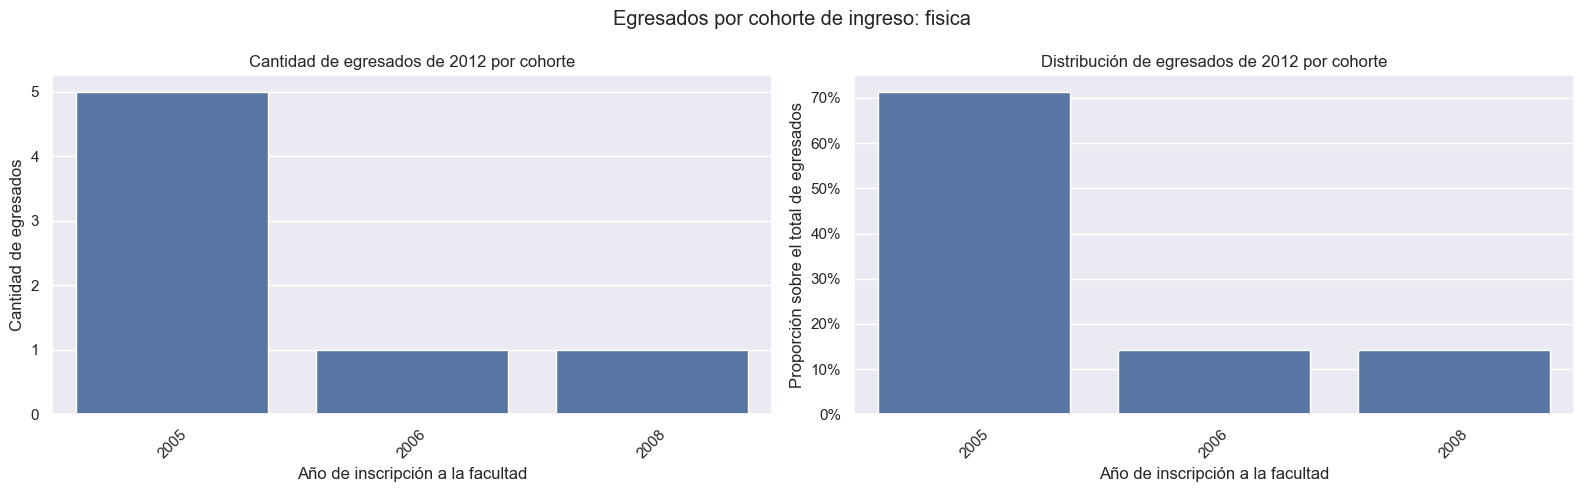

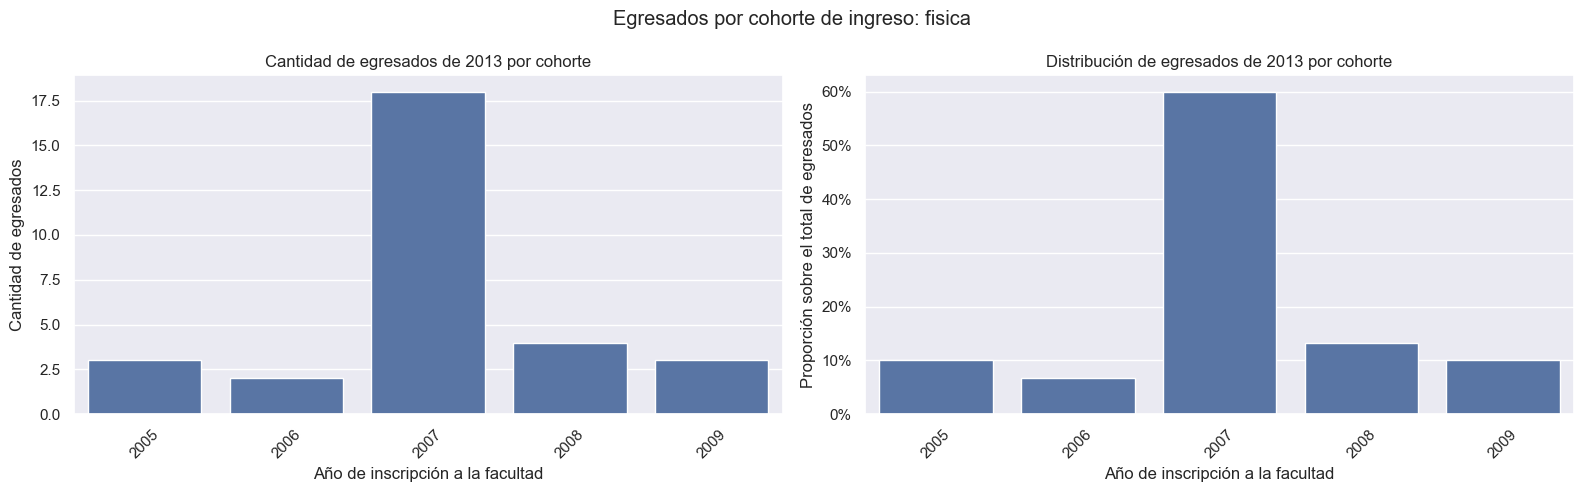

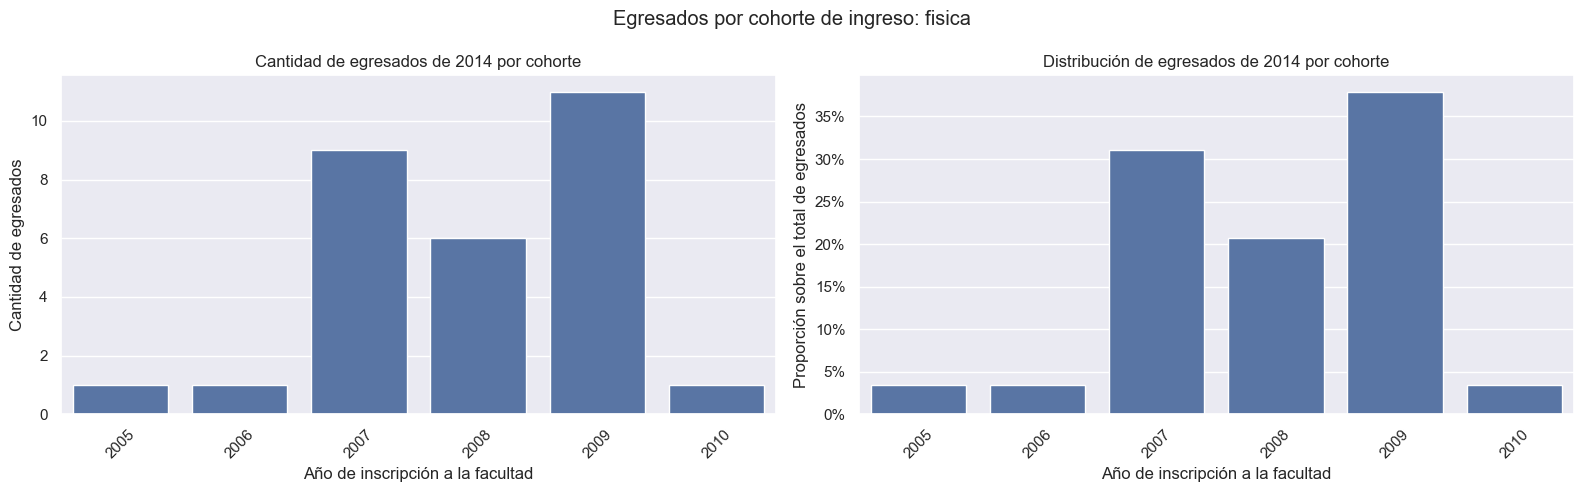

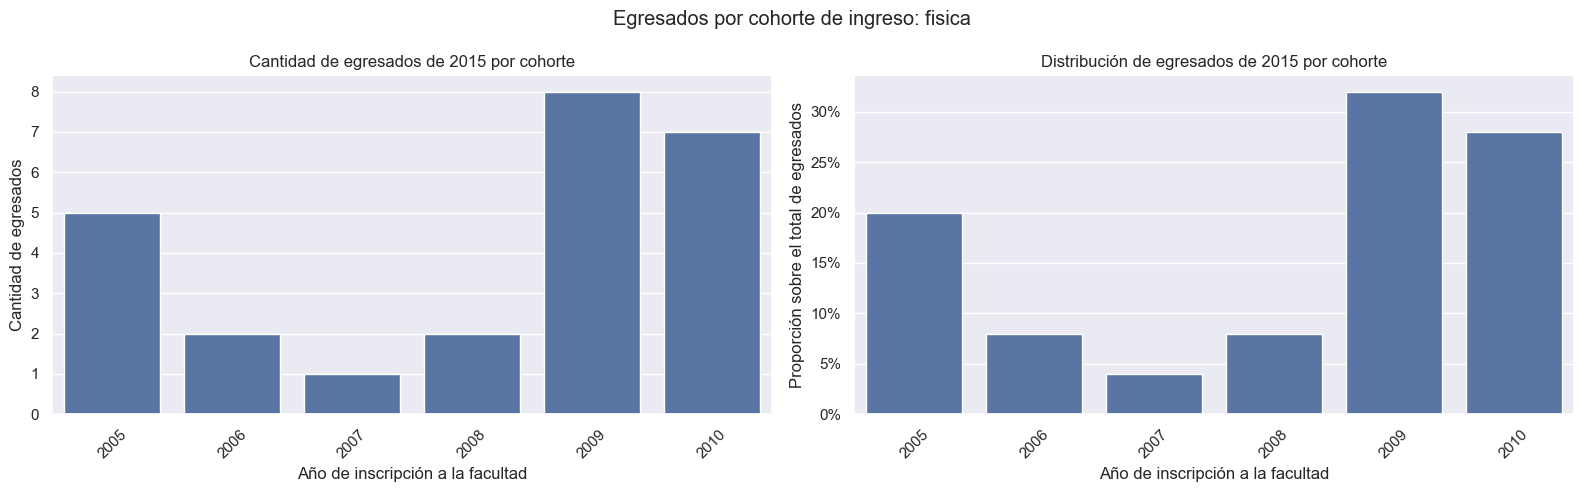

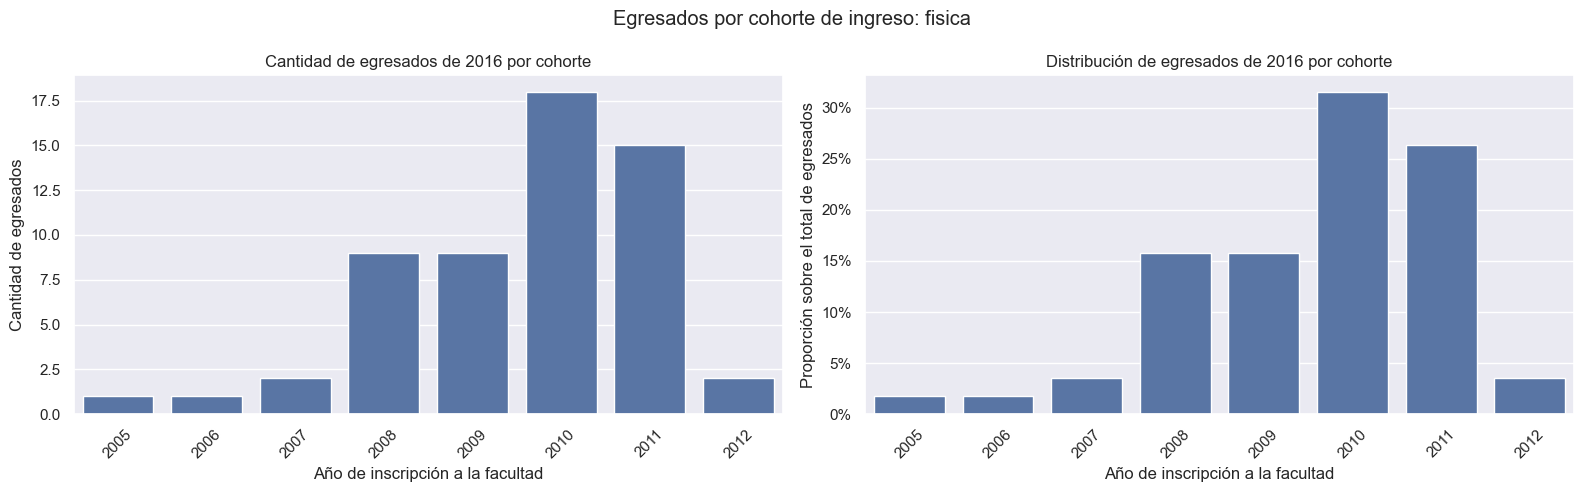

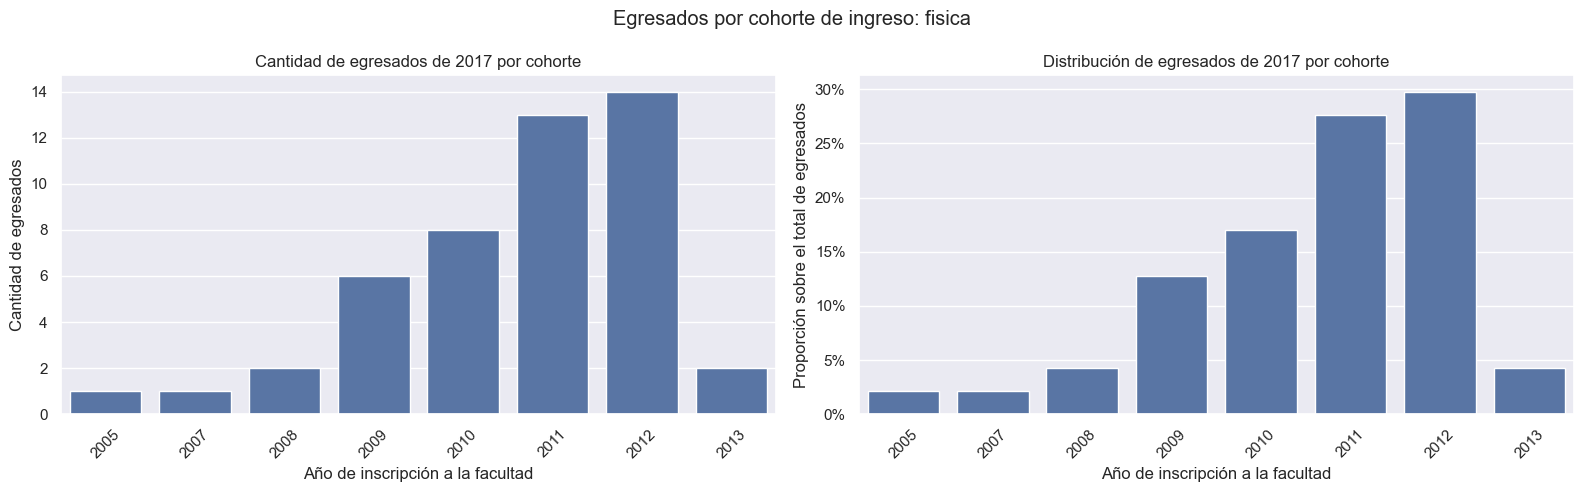

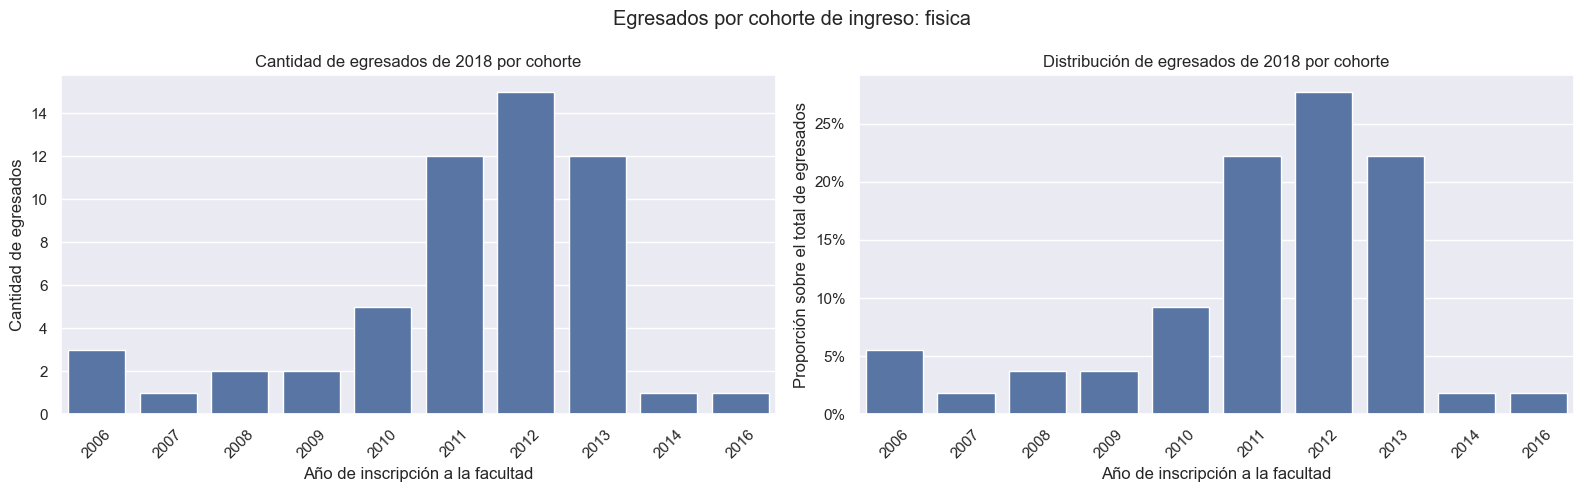

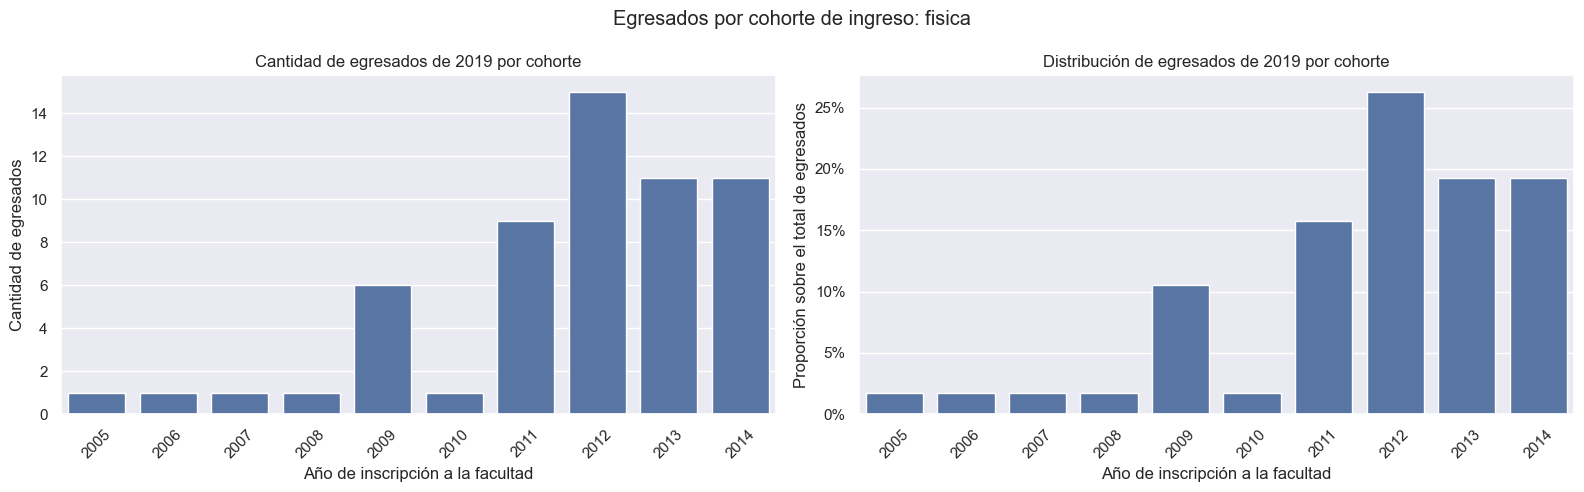

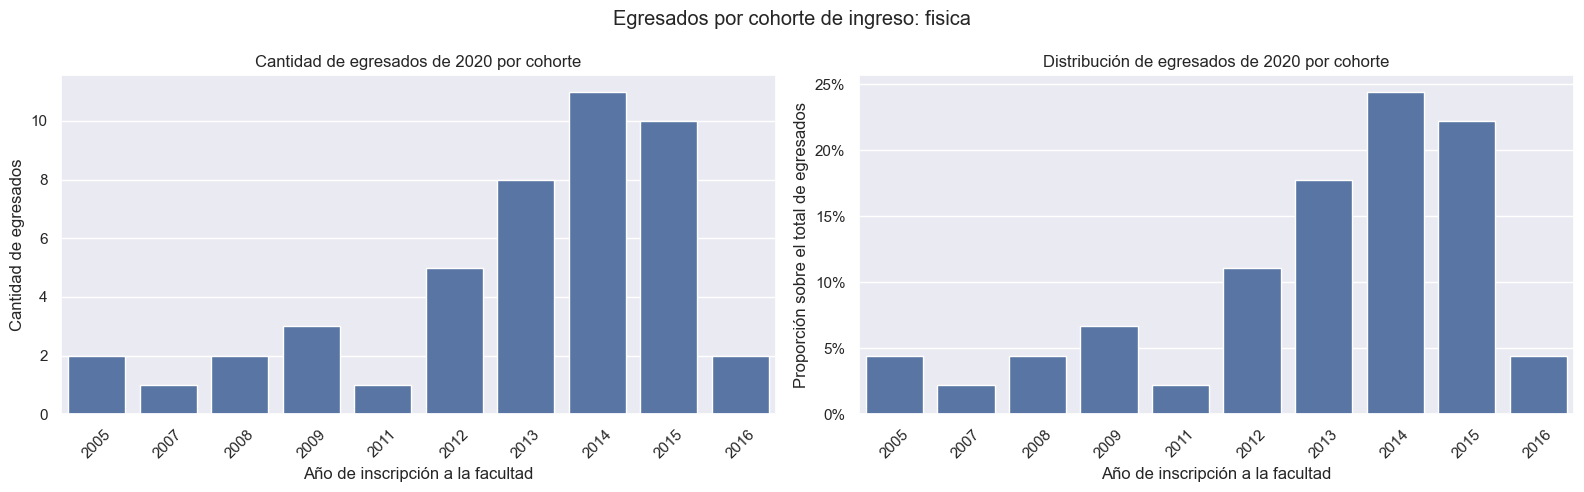

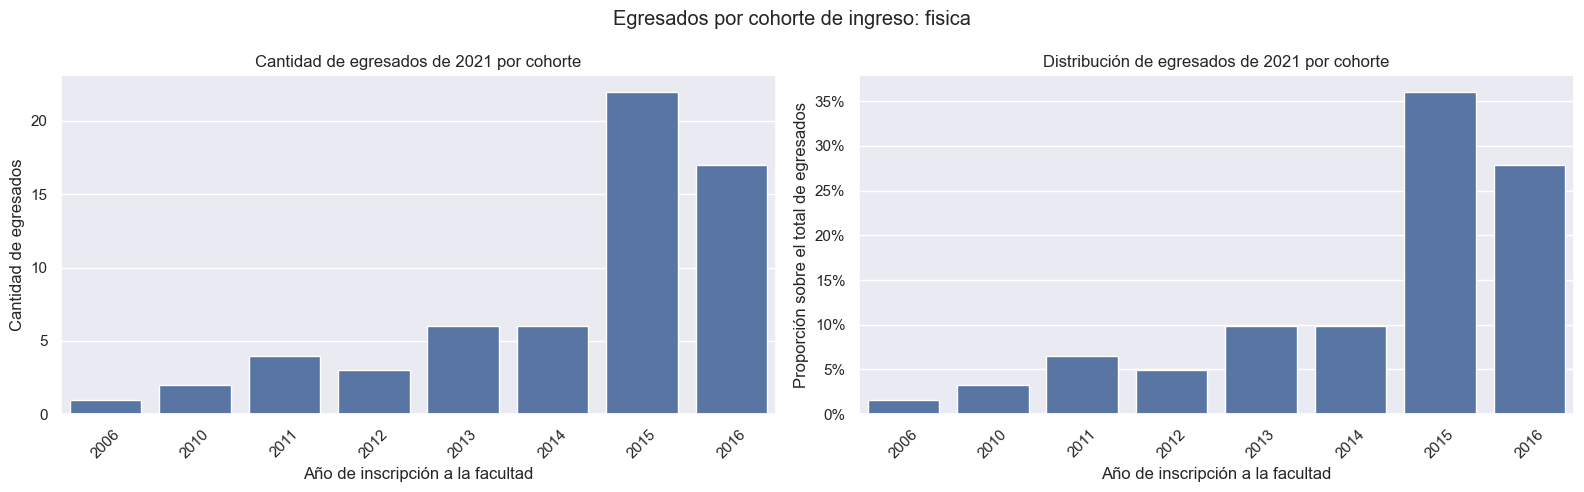

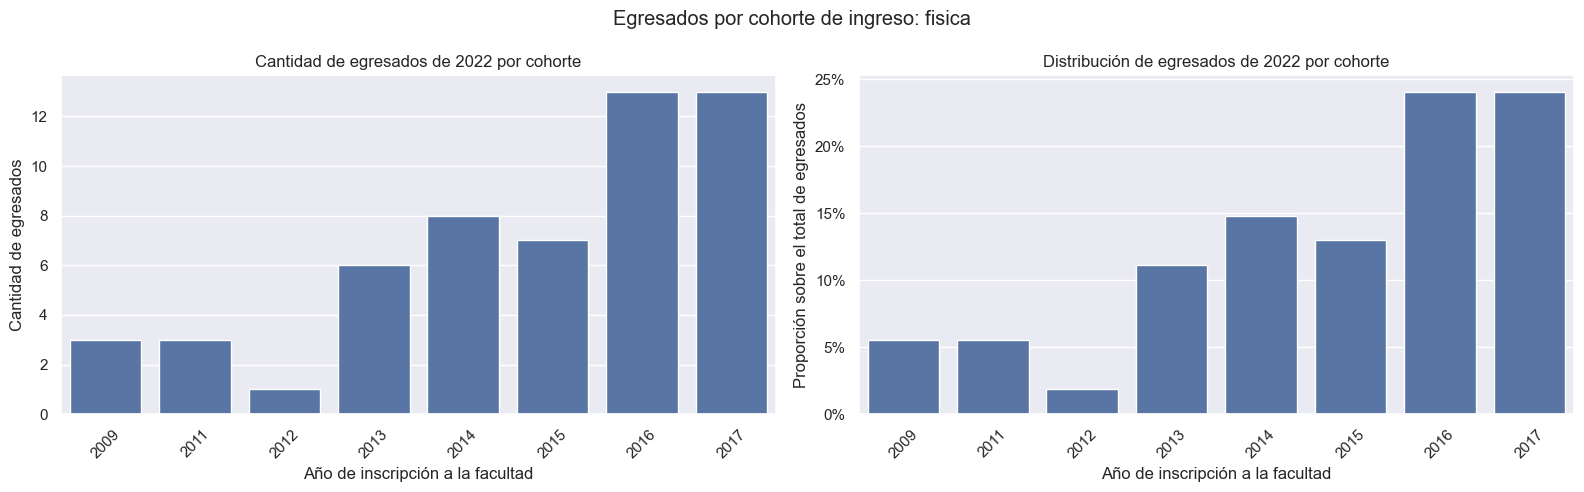

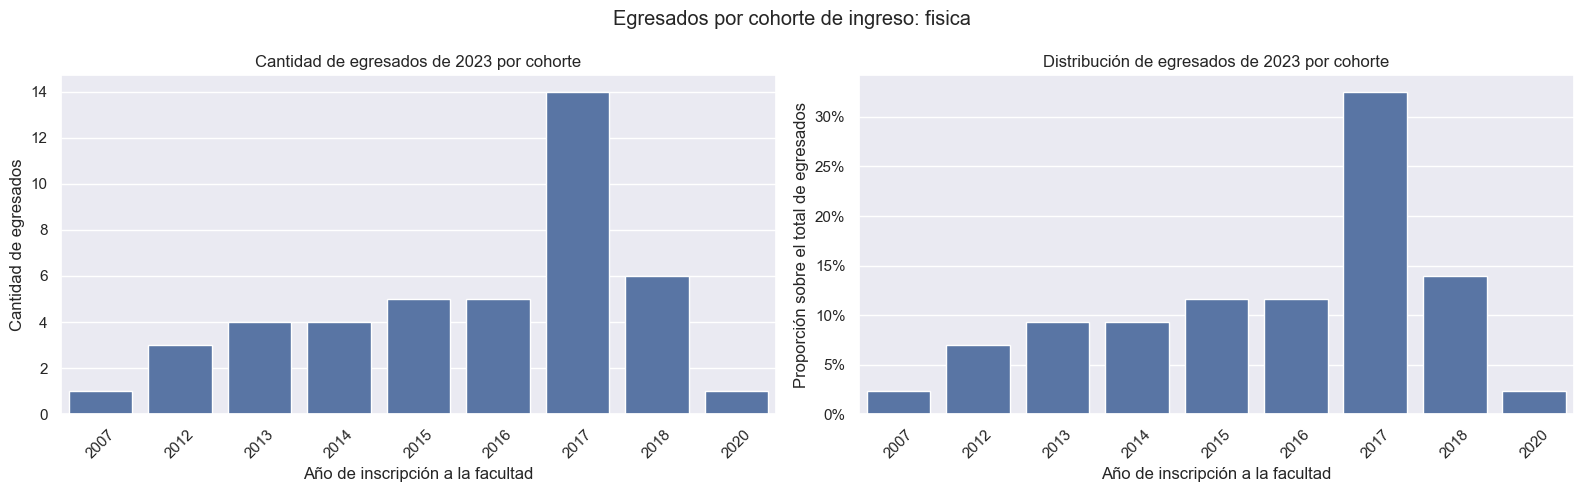

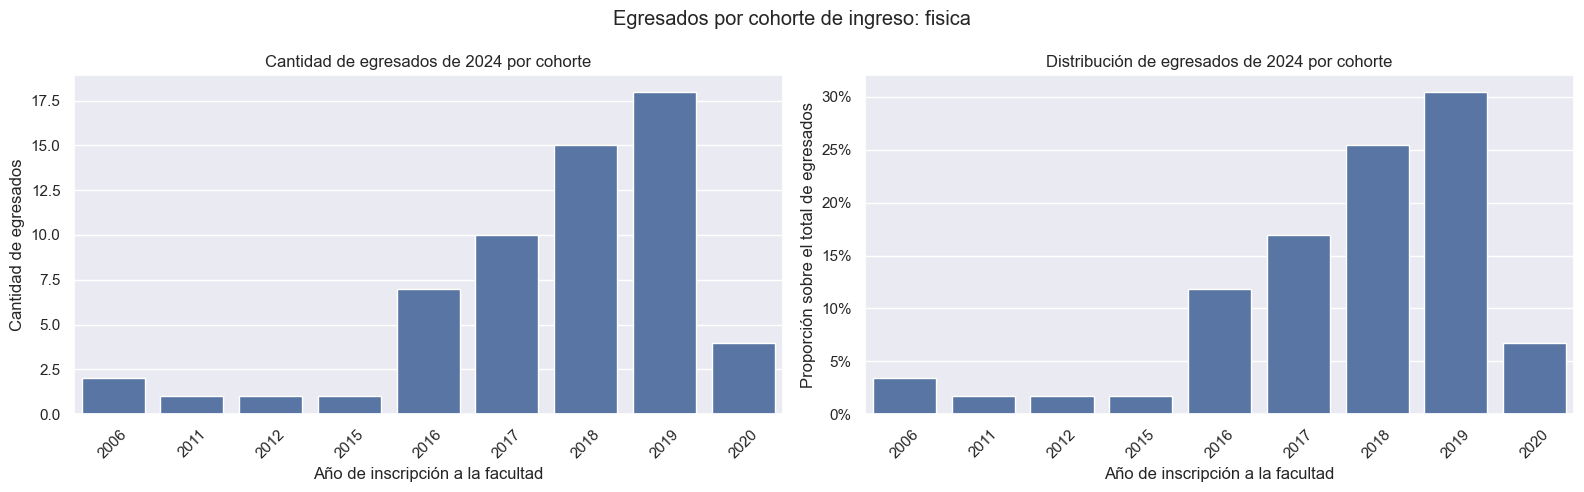

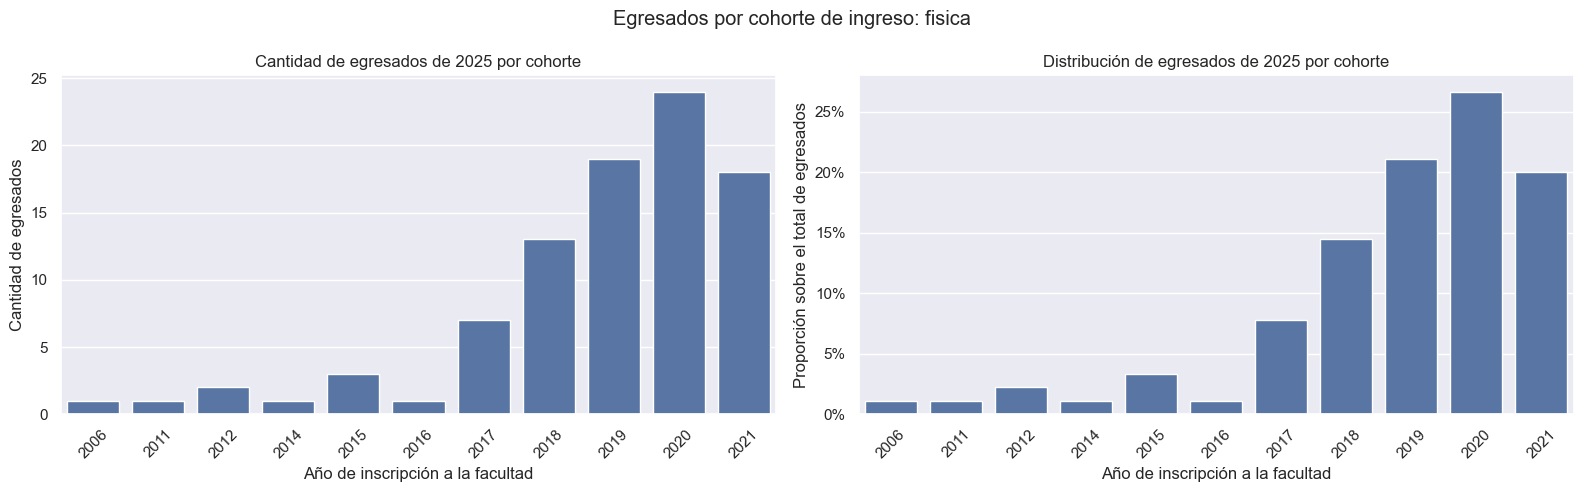

In [21]:
plot_todos_anios_egreso(egresados_fisica, 'Física')

In [22]:
egresados_fisica_2014_2019 = pd.DataFrame()
for anio in range(2014, 2020):
    egresados = pd.read_csv(f'../../../assets/datos_agrupados/fisica/resumen_egresados_fisica_{anio}.csv')
    egresados_fisica_2014_2019 = pd.concat([egresados_fisica_2014_2019, egresados])

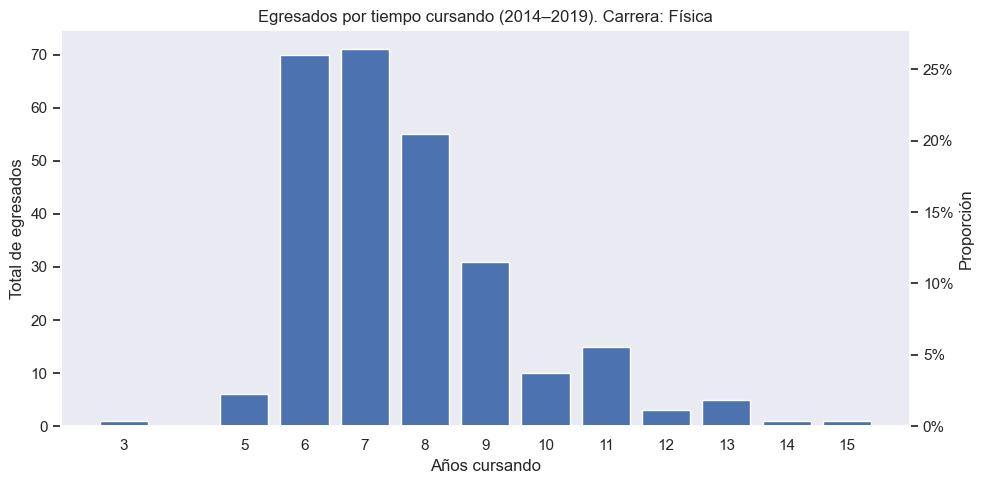

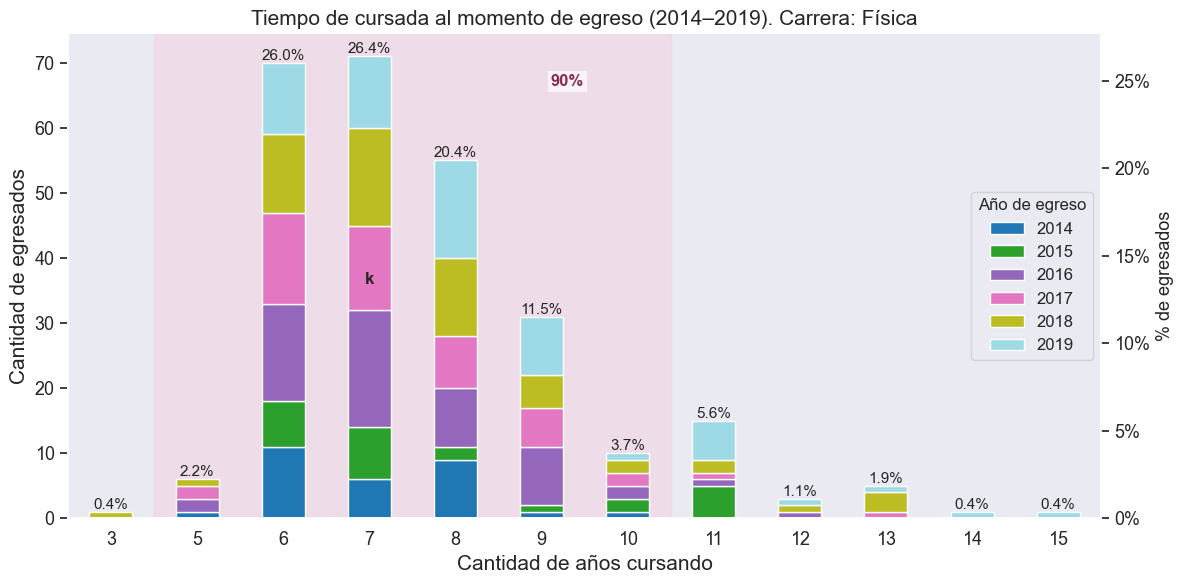

 tiempo_cursando  total_egreso
               3             1
               5             6
               6            70
               7            71
               8            55
               9            31
              10            10
              11            15
              12             3
              13             5
              14             1
              15             1
anio_egreso      2014  2015  2016  2017  2018  2019
tiempo_cursando                                    
3                   0     0     0     0     1     0
5                   1     0     2     2     1     0
6                  11     7    15    14    12    11
7                   6     8    18    13    15    11
8                   9     2     9     8    12    15
9                   1     1     9     6     5     9
10                  1     2     2     2     2     1
11                  0     5     1     1     2     6
12                  0     0     1     0     1     1
13                  0    

In [23]:
total_por_tiempo, resumen_por_cohorte, prom_ponderado = plot_tiempo_cursando(egresados_fisica_2014_2019, 'Física', anio_desde=2014, anio_hasta=2019)

## Modelo

Queremos ver si podemos ajustar una función a los datos de egresados por año. Para ellos hacemos el Test de Chi-Cuadrado.

In [24]:
# 1. Creamos la serie expandida de años
datos_expandidos = np.repeat(total_por_tiempo['tiempo_cursando'], total_por_tiempo['total_egreso'])

# 2. Calculamos los límites del 95% (dejamos fuera 2.5% de cada lado)
limite_inferior = np.percentile(datos_expandidos, 2.5)
limite_superior = np.percentile(datos_expandidos, 97.5)

print(f"Rango recomendado para el 95%: {limite_inferior} a {limite_superior} años")

# 3. Filtramos el DataFrame original
df_filtrado = total_por_tiempo[
    (total_por_tiempo['tiempo_cursando'] >= limite_inferior) & 
    (total_por_tiempo['tiempo_cursando'] <= limite_superior)
]

Rango recomendado para el 95%: 5.7 a 12.300000000000011 años


Rechazamos la hipótesis nula que asume que no existe asociación entre las variables, por lo cual vemos si el ingreso acumulado tiene una forma similar a la Binomial Negativa.

In [25]:
from scipy.stats import chi2_contingency

resumen_por_cohorte_95 = resumen_por_cohorte[
    (resumen_por_cohorte.index >= limite_inferior) & 
    (resumen_por_cohorte.index <= limite_superior)
]

chi2, p, dof, expected = chi2_contingency(resumen_por_cohorte_95)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 34.84483868737364
p-value: 0.24832998776695706


In [26]:
stats = {}

for col in resumen_por_cohorte_95.columns:
    datos = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[col])
    
    stats[col] = {
        "media": np.mean(datos),
        "mediana": np.median(datos),
        "std": np.std(datos)
    }

pd.DataFrame(stats).T

,media,mediana,std
2014,7.107143,7.0,1.080320
2015,7.920000,7.0,1.895679
2016,7.490909,7.0,1.386595
2017,7.363636,7.0,1.298442
2018,7.591837,7.0,1.441631
2019,8.000000,8.0,1.598611


In [27]:
from scipy.stats import nbinom

total_por_tiempo_95 = total_por_tiempo[
    (total_por_tiempo['tiempo_cursando'] >= limite_inferior) & 
    (total_por_tiempo['tiempo_cursando'] <= limite_superior)
]

# 1. Expandir datos para cálculos estadísticos
datos_completos = np.repeat(total_por_tiempo_95["tiempo_cursando"], total_por_tiempo_95["total_egreso"])

# 2. Desplazar datos (Restamos el mínimo o la duración nominal, ej. 5)
shift = limite_inferior
shift_entero = int(round(shift))

datos_desplazados = datos_completos - shift_entero
# Nota: Si algún dato queda negativo (como el año 3), 
# se suele truncar a 0 o elegir un shift más pequeño.
datos_desplazados = np.maximum(datos_desplazados, 0)

mu = np.mean(datos_desplazados)
var = np.var(datos_desplazados)

print(f"Media: {mu:.2f}, Varianza: {var:.2f}")

if var > mu:
    # 3. Estimar parámetros n y p para la Binomial Negativa
    print("La varianza es mayor a la media. ¡La Binomial Negativa es una buena candidata!")
    p = mu / var
    n = (mu**2) / (var - mu)
    print(f"Parámetros estimados: n={n:.2f}, p={p:.2f}")
else:
    print("Incluso desplazando, la varianza es menor. Considera una Binomial común.")

Media: 1.60, Varianza: 2.21
La varianza es mayor a la media. ¡La Binomial Negativa es una buena candidata!
Parámetros estimados: n=4.15, p=0.72


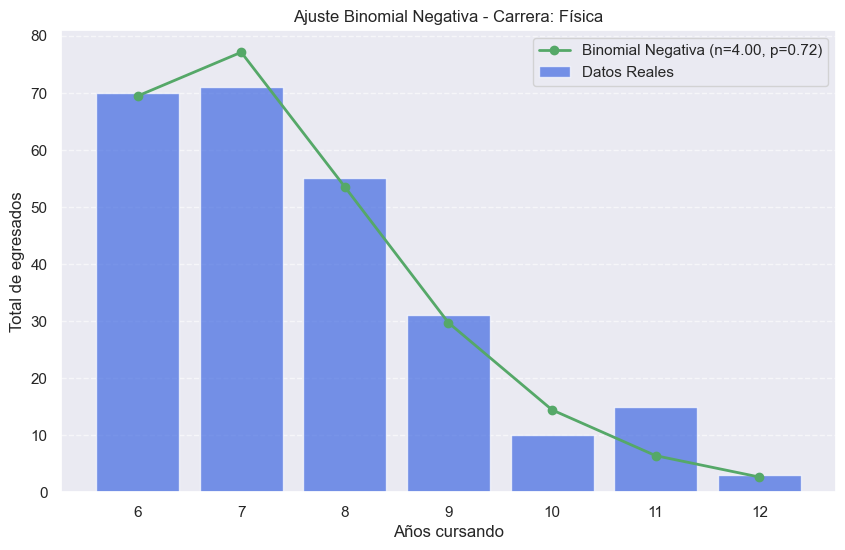

In [28]:
from scipy.stats import binom
import matplotlib.pyplot as plt
p_est = mu / var
n_est = int(round((mu**2) / (var - mu)))

# Eje X para la curva (desde el desplazamiento hacia adelante)
x_teorico = np.arange(0, total_por_tiempo_95['tiempo_cursando'].max() - shift_entero + 1)
y_teorico = nbinom.pmf(x_teorico, n_est, p_est) * total_por_tiempo_95['total_egreso'].sum()

# 4. Graficamos
plt.figure(figsize=(10, 6))

# Barras reales
plt.bar(total_por_tiempo_95['tiempo_cursando'], total_por_tiempo_95['total_egreso'], color='royalblue', alpha=0.7, label='Datos Reales')

# Curva Binomial Negativa
# Nota: sumamos shift para devolver la curva a su posición original en el eje X
plt.plot(x_teorico + shift_entero, y_teorico, 'go-', lw=2, 
            label=f'Binomial Negativa (n={n_est:.2f}, p={p_est:.2f})')

plt.title('Ajuste Binomial Negativa - Carrera: Física')
plt.xlabel('Años cursando')
plt.ylabel('Total de egresados')
plt.xticks(np.arange(int(round(limite_inferior)), int(round(limite_superior)) + 1, 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [29]:
x_teorico

array([0, 1, 2, 3, 4, 5, 6])

In [30]:
y_teorico

array([69.44844699, 77.11423759, 53.51636625, 29.71177874, 14.43373543,
        6.41077836,  2.66940249])

In [31]:
total_por_tiempo_95['total_egreso']

2    70
3    71
4    55
5    31
6    10
7    15
8     3
Name: total_egreso, dtype: int64

In [32]:
mse_manual = np.mean((total_por_tiempo_95['total_egreso'].to_numpy() - y_teorico)**2)

print(f"MSE: {mse_manual:.4f}")

MSE: 19.2987


In [33]:
# Cálculo del MAPE
# Nota: solo funciona si no tienes años con 0 egresados (para evitar dividir por cero)
mape = np.mean(np.abs((total_por_tiempo_95['total_egreso'].to_numpy() - y_teorico) / total_por_tiempo_95['total_egreso'].to_numpy())) * 100

print(f"El error porcentual medio (MAPE) es: {mape:.2f}%")

El error porcentual medio (MAPE) es: 18.41%


In [34]:
error_total_relativo = (np.sum(np.abs(total_por_tiempo_95['total_egreso'].to_numpy()- y_teorico)) / np.sum(total_por_tiempo_95['total_egreso'].to_numpy())) * 100
print(f"Error relativo total: {error_total_relativo:.2f}%")

Error relativo total: 8.94%


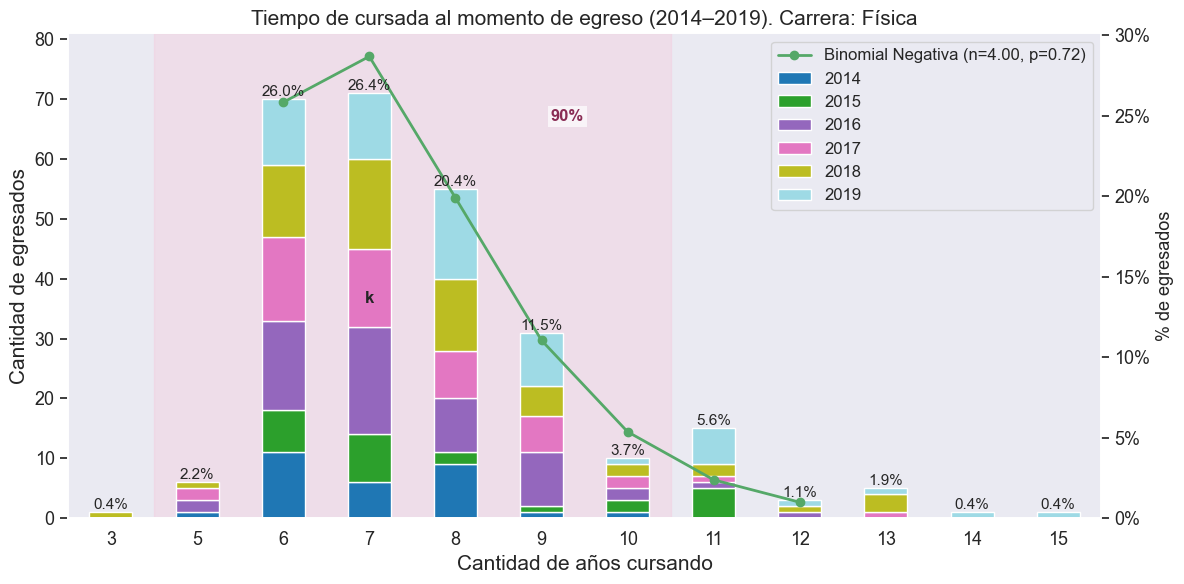

In [35]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
resumen_por_cohorte.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("Cantidad de años cursando", fontsize=15)
ax.set_ylabel("Cantidad de egresados", fontsize=15)
ax.set_title(f"Tiempo de cursada al momento de egreso (2014–2019). Carrera: Física", fontsize=15)
ax.tick_params(axis="x", rotation=0, labelsize=13)
ax.tick_params(axis="y", labelsize=13)

totales_por_tiempo = resumen_por_cohorte.sum(axis=1)
cantidades = totales_por_tiempo.tolist()
pos_k = resumen_por_cohorte.index.get_loc(totales_por_tiempo.idxmax())
total = sum(cantidades)
objetivo = 0.9 * total
n_barras = len(cantidades)
k_en_borde = pos_k == 0 or pos_k == n_barras - 1
mejor_tramo = None
for izq in range(0, pos_k + 1):
    for der in range(pos_k, n_barras):
        if not k_en_borde and not (izq < pos_k and der > pos_k):
            continue
        suma_tramo = sum(cantidades[izq : der + 1])
        distancia = abs(suma_tramo - objetivo)
        usa_ambos_lados = izq < pos_k and der > pos_k
        criterio = (distancia, 0 if usa_ambos_lados else 1, der - izq)
        if mejor_tramo is None or criterio < mejor_tramo[0]:
            mejor_tramo = (criterio, izq, der)

if mejor_tramo is not None:
    _, izq_sombreado, der_sombreado = mejor_tramo
    ax.axvspan(
        izq_sombreado - 0.5,
        der_sombreado + 0.5,
        color="#f7c6d9",
        alpha=0.35,
        zorder=0,
    )
    x_centro = (izq_sombreado + der_sombreado) / 2 + 1.8
    y_texto = ax.get_ylim()[1] * 0.90
    ax.text(
        x_centro,
        y_texto,
        "90%",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#8a2d55",
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "pad": 2},
    )

valor_k = resumen_por_cohorte.index[pos_k]
altura_k = cantidades[pos_k]/2
ax.text(
    pos_k,
    altura_k,
    f"k",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold",
)

# Curva Binomial Negativa
# Nota: sumamos shift para devolver la curva a su posición original en el eje X
x_plot = np.arange(len(x_teorico))  # 0,1,2,... igual que las barras

plt.plot(x_plot + 2, y_teorico, 'go-', lw=2, 
            label=f'Binomial Negativa (n={n_est:.2f}, p={p_est:.2f})')

grand_total = total_por_tiempo["total_egreso"].sum()
for i, tc in enumerate(resumen_por_cohorte.index):
    total_height = resumen_por_cohorte.loc[tc].sum()
    proporcion_simple = (total_height / grand_total) if grand_total else 0
    ax.text(i, total_height, f"{proporcion_simple:.1%}", ha="center", va="bottom", fontsize=11)
ax_right2 = ax.twinx()
ax_right2.set_ylim(ax.get_ylim()[0] / grand_total, ax.get_ylim()[1] / grand_total)
ax_right2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax_right2.tick_params(axis="y", labelsize=13)
ax_right2.set_ylabel("% de egresados", fontsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Ajuste de graficos

Mejor tramo para k=8: 1 a 2, suma=6 (objetivo=6.3)


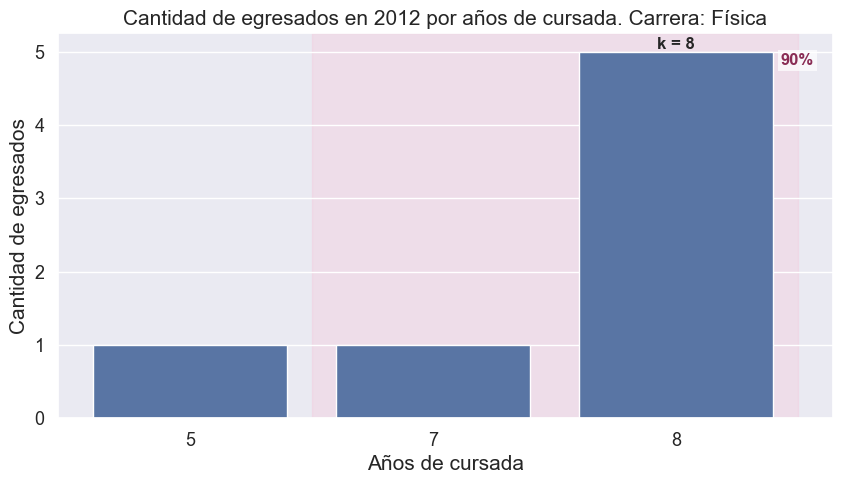

Mejor tramo para k=7: 0 a 3, suma=27 (objetivo=27.0)


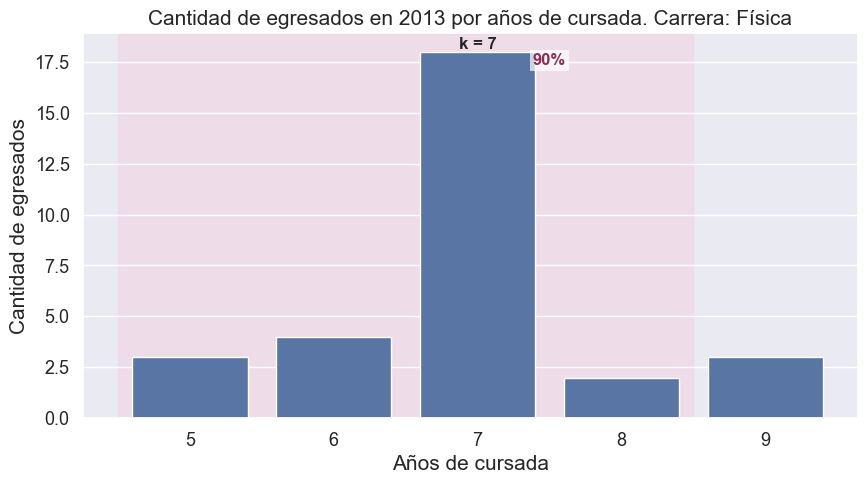

Mejor tramo para k=6: 0 a 3, suma=27 (objetivo=26.1)


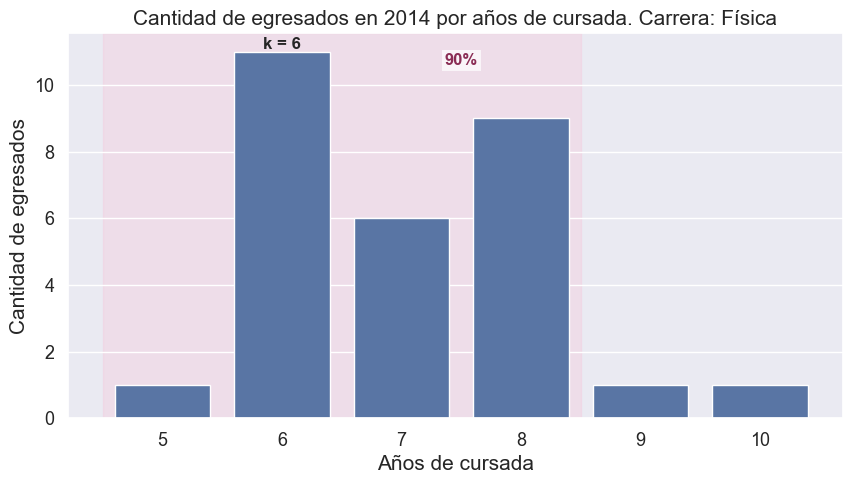

Mejor tramo para k=7: 0 a 4, suma=20 (objetivo=22.5)


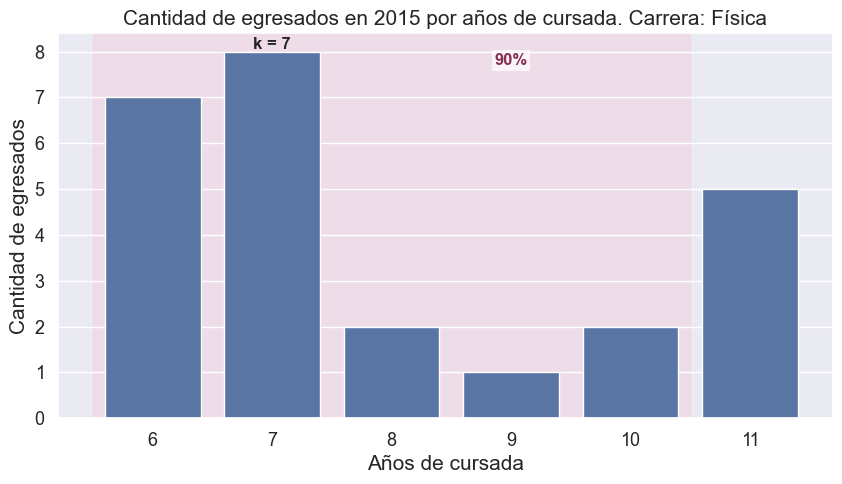

Mejor tramo para k=7: 1 a 4, suma=51 (objetivo=51.3)


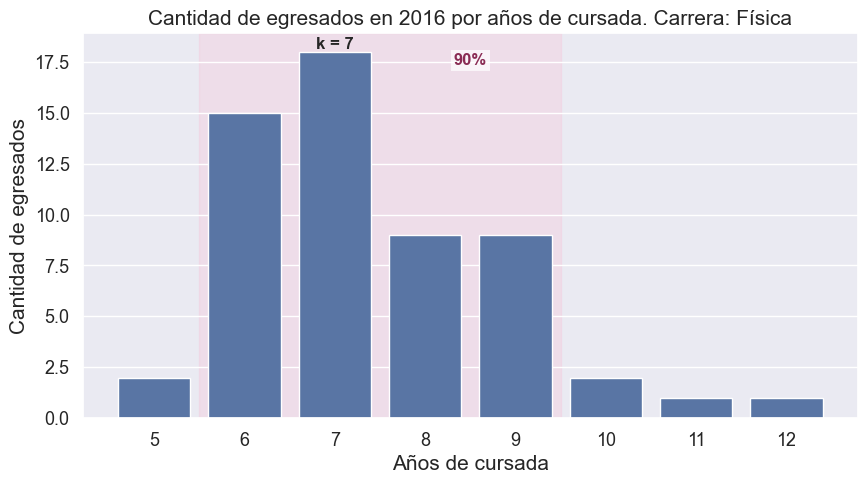

Mejor tramo para k=6: 0 a 4, suma=43 (objetivo=42.3)


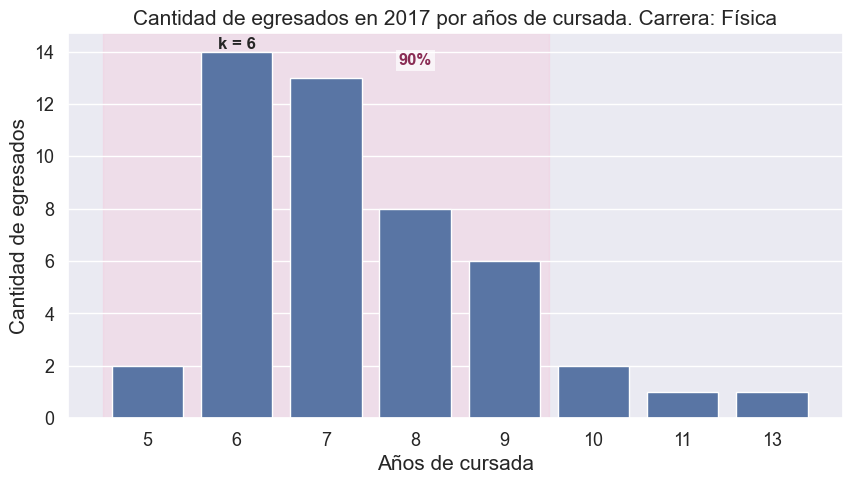

Mejor tramo para k=7: 1 a 7, suma=49 (objetivo=48.6)


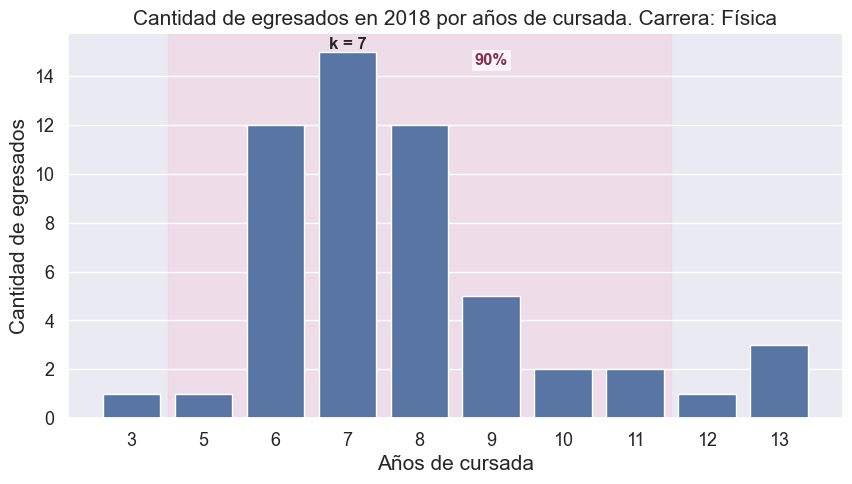

Mejor tramo para k=8: 0 a 5, suma=53 (objetivo=51.3)


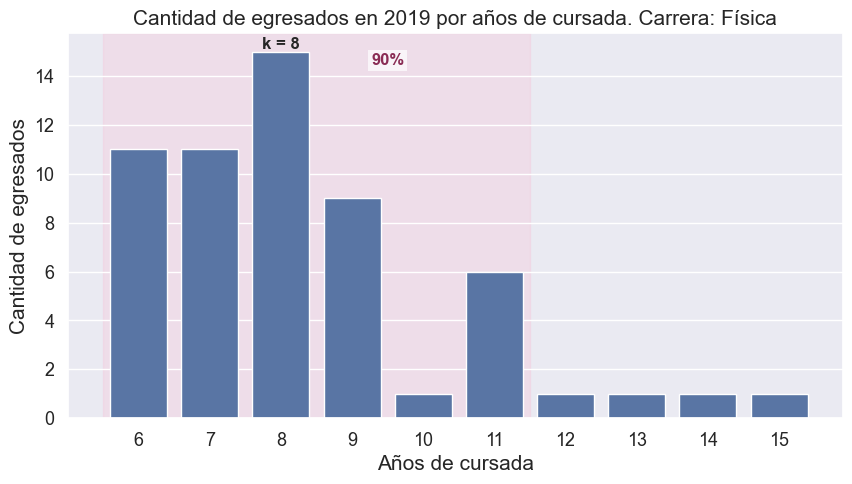

Mejor tramo para k=7: 0 a 6, suma=40 (objetivo=40.5)


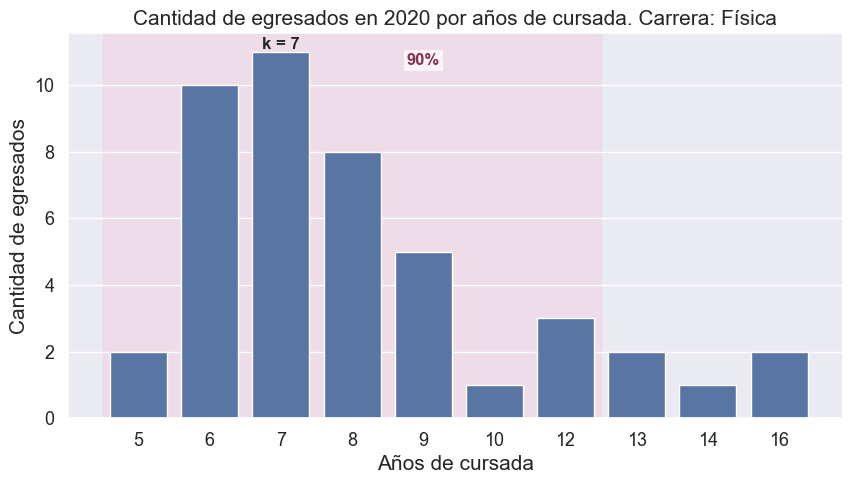

Mejor tramo para k=7: 0 a 4, suma=54 (objetivo=54.9)


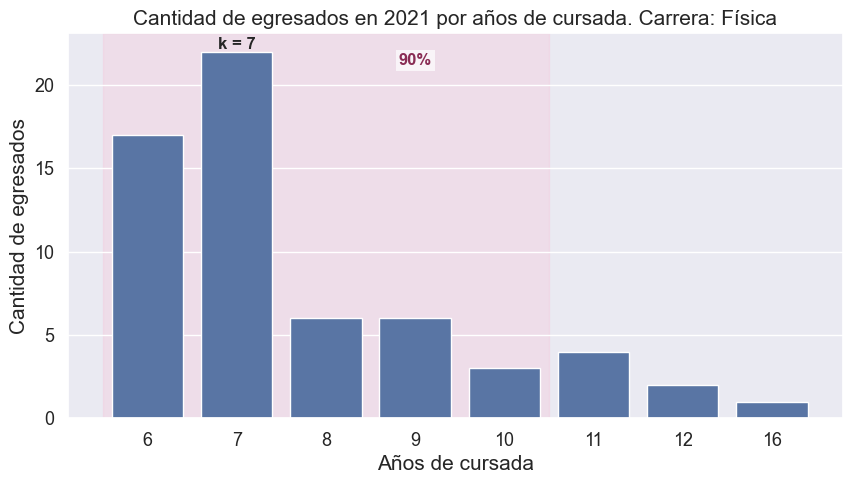

Mejor tramo para k=6: 0 a 5, suma=48 (objetivo=48.6)


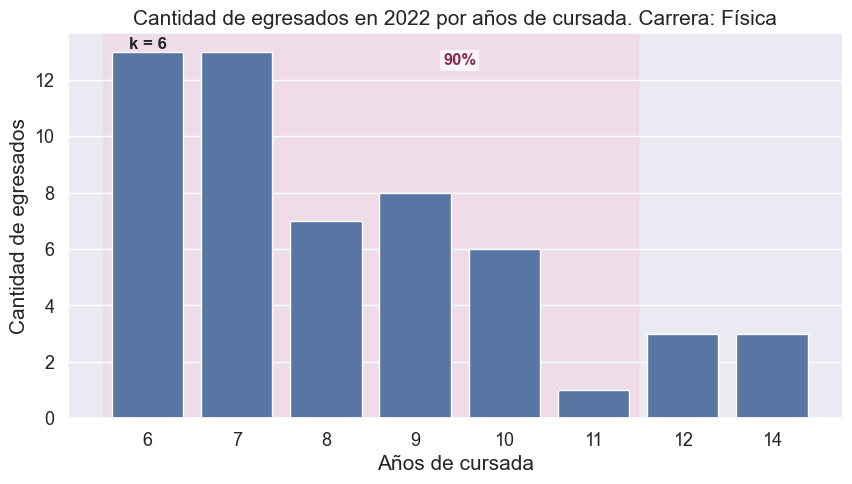

Mejor tramo para k=7: 0 a 6, suma=39 (objetivo=38.7)


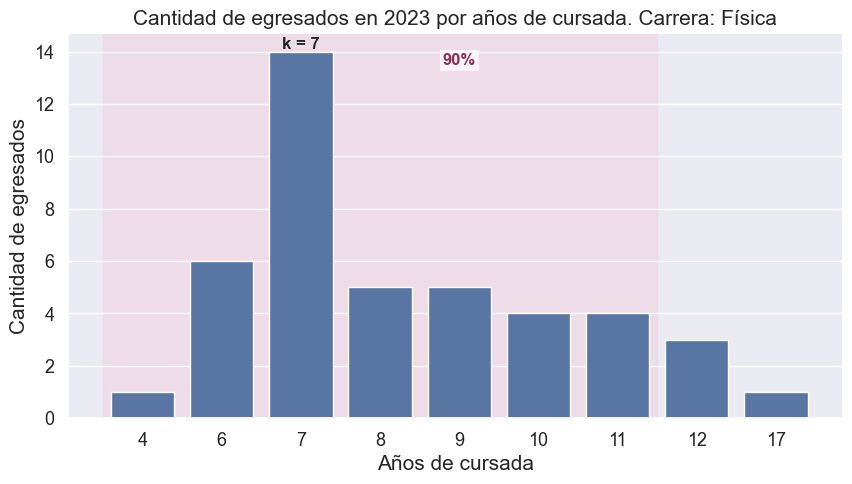

Mejor tramo para k=6: 0 a 4, suma=54 (objetivo=53.1)


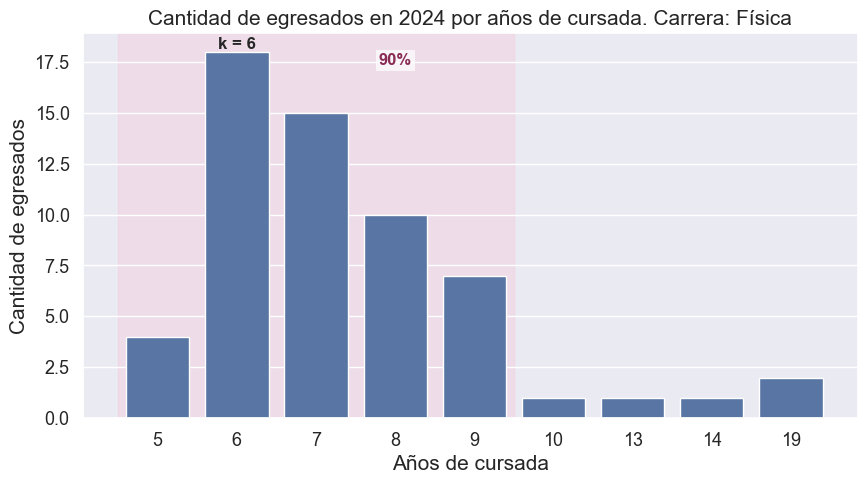

Mejor tramo para k=6: 0 a 4, suma=81 (objetivo=81.0)


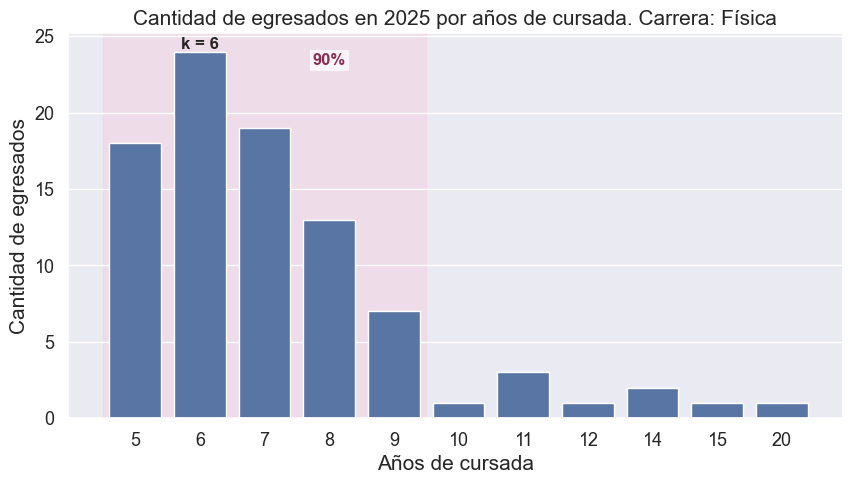

In [36]:
plot_todos_anios_egreso_solo_cantidad_y_k(2012, 2025, "Física")